# Phase 1.2 — Dubins per-sample slack diagnostic

This **notebook is the single driver**: it sets every parameter in `PARAMS`, triggers the MATLAB per-sample slack SOP (`solve_dubins_slack.m`, which sets no parameters of its own — it only reads them from the environment), then loads the resulting per-sample slack table to (i) plot the slack distribution, (ii) locate the hard samples, and (iii) pick an effective bound $u_{\max}^{\rm eff}$ and the kept subset.

Self-contained: MATLAB runs with only `revision/matlab_frozen` + `revision/slack_diagnostic` on the path (never the main repo); the synthesis region is the Phase 1.1 `X_S_eff`; all I/O is under `revision/data/`.


## §0 — Per-sample slack SOP (what `solve_dubins_slack.m` solves)

Backstepping gives an output-feedback reach-avoid controller $u(\bm x) = A(\bm x)^{-1}\,b(\bm x; k_1)$ parameterized by the output-space map $k_1(\bm y)$. The bounded-control synthesis fixes $k_1$ by a sampled SOP. The **per-sample slack** variant probes a requested bound $\mathrm{ub}$ and reports, per state, how far the reach-avoid controller must exceed it.

Over $N$ valid reach-avoid samples $\{\bm x_j\}$ (safe, outside target, certificate $\ge 0$) and channels $i$:

$$
\min_{k_1,\,\delta\ge0,\,s_{j,i}\ge0}\quad \delta + w\sum_{j,i} s_{j,i}
$$

$$
\text{s.t.}\quad |u_i(\bm x_j)| \le \mathrm{ub}_i + s_{j,i}\quad(\text{soft, per sample}),
$$

$$
\underbrace{\nabla\psi\cdot k_1 - \lambda\,\psi + \delta - s_1\psi - s_2\,\text{target} \in \Sigma[\bm y]}_{\text{reach-avoid descent (hard, SOS)}},\qquad
\underbrace{M(\bm x_j)\succeq 0}_{\text{certificate (hard, per sample)}}.
$$

The reach-avoid property is kept **hard**; only the input bound is relaxed. The optimal slacks $s_{j,i}^\star$ form a **distribution**: the per-sample achievable bound is $\mathrm{ub}_i + s_{j,i}^\star$. Reading off a coverage quantile of this distribution gives the bound we can guarantee for that fraction of states, and which states to keep in the actual (Phase 1.3 hard) synthesis.


## §1 — Parameters (single source of truth) + MATLAB trigger helper

Edit `PARAMS` here to change anything; the values are pushed to MATLAB as environment variables. `solve_dubins_slack.m` errors if any is missing — there are no parameter defaults on the MATLAB side.


In [11]:
import json
import os
import shutil
import subprocess

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# locate repo ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
SLACK_DIR = os.path.join(REV, "slack_diagnostic")
REV_DATA = os.path.join(REV, "data")
os.makedirs(REV_DATA, exist_ok=True)
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

PARAMS = {
    "mu": 0.1,  # backstepping certificate parameter (paper baseline)
    "xi0": 1e-8,  # SOS floor lambda >= xi0 for the vanilla k1 (descent rate)
    "ub": 5.0,  # requested (tight) input bound to probe; |u_i| <= ub + slack
    "n_valid_samples": 250,  # number of valid reach-avoid SOP samples
    "slack_weight": 100.0,  # weight w on sum of per-sample slacks in the objective
    "ds": 4,  # SOS auxiliary degree
    "dv": 4,  # k1 polynomial degree
    # --- notebook-side selection (no MATLAB re-run needed to change these) ---
    "coverage_pct": 80,  # keep the lowest-q% of samples by combined slack
    "slack_floor": 1e-2,  # below this, slack is the solver's numerical zero
}
ENV = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB": PARAMS["ub"],
    "N_VALID": PARAMS["n_valid_samples"],
    "SLACK_WEIGHT": PARAMS["slack_weight"],
    "DS": PARAMS["ds"],
    "DV": PARAMS["dv"],
}


def run_matlab(script_name, env_overrides):
    """Run a revision MATLAB driver with ONLY the revision dirs on the path."""
    env = os.environ.copy()
    env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{SLACK_DIR}'); "
        f"try, {script_name}; catch e, fprintf(2,'%s\\n',e.message); exit(1); end; exit(0);",
    ]
    r = subprocess.run(cmd, env=env, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"MATLAB {script_name} failed:\n{r.stderr[-2000:]}")
    return r.stdout


print("ROOT       :", ROOT)
print("MATLAB_BIN :", MATLAB_BIN, "(exists:", os.path.exists(MATLAB_BIN), ")")
for k, v in PARAMS.items():
    print(f"  {k:16s} = {v}")

ROOT       : /home/jianqiang/Downloads/reach_avoid_backstepping_MPC
MATLAB_BIN : /usr/local/bin/matlab (exists: True )
  mu               = 0.1
  xi0              = 1e-08
  ub               = 5.0
  n_valid_samples  = 250
  slack_weight     = 100.0
  ds               = 4
  dv               = 4
  coverage_pct     = 80
  slack_floor      = 0.01


## §2 — Trigger the MATLAB per-sample slack SOP, then load the result

Re-runs MATLAB only when an output is missing or the cached `slack_meta_dubins.csv` was produced with different parameters (set `REGENERATE = True` to force). Outputs: `slack_persample_dubins.csv` (per-sample slacks + sample coords) and `slack_meta_dubins.csv` (probe params + summary).


In [12]:
PS_PATH = os.path.join(REV_DATA, "slack_persample_dubins.csv")
META_PATH = os.path.join(REV_DATA, "slack_meta_dubins.csv")
REGENERATE = False

watched = [
    ("mu", "mu", 1e-9),
    ("xi0", "xi0", 1e-9),
    ("ub", "ub_req", 1e-9),
    ("n_valid_samples", "n_valid_samples", 0.5),
    ("slack_weight", "slack_weight", 1e-9),
    ("ds", "ds", 0.5),
    ("dv", "dv", 0.5),
]
need = REGENERATE or not (os.path.exists(PS_PATH) and os.path.exists(META_PATH))
if not need:
    cached = pd.read_csv(META_PATH).iloc[0]
    for pkey, ckey, tol in watched:
        if (
            ckey not in cached.index
            or abs(float(cached[ckey]) - float(PARAMS[pkey])) > tol
        ):
            need = True
            print(f"cache miss on '{ckey}' -> regenerate")
            break

if need:
    print("running solve_dubins_slack.m (MATLAB) ...")
    out = run_matlab("solve_dubins_slack", ENV)
    print("\n".join(out.strip().splitlines()[-8:]))
else:
    print("cached outputs match PARAMS -> skipping MATLAB.")

df = pd.read_csv(PS_PATH)
meta = pd.read_csv(META_PATH).iloc[0]
UB_REQ = float(meta["ub_req"])
df["slack"] = df[["slack1", "slack2"]].max(
    axis=1
)  # combined = worst channel (symmetric ub)
print(
    f"\nloaded {len(df)} samples; ub_req={UB_REQ}, lambda={meta['lambda']:.4g}, delta={meta['delta']:.4g}"
)
for c in ["slack1", "slack2", "slack"]:
    s = df[c].values
    print(
        f"  {c}: p50={np.percentile(s,50):.4g} p80={np.percentile(s,80):.4g} "
        f"p90={np.percentile(s,90):.4g} p95={np.percentile(s,95):.4g} max={s.max():.4g}"
    )

cached outputs match PARAMS -> skipping MATLAB.

loaded 250 samples; ub_req=5.0, lambda=1.095e-08, delta=152.3
  slack1: p50=0.002697 p80=2.625 p90=7.419 p95=13.34 max=32.93
  slack2: p50=0.002695 p80=0.002697 p90=0.005504 p95=1.291 max=3.211
  slack: p50=0.002698 p80=2.625 p90=7.419 p95=13.34 max=32.93


## §3 — Per-sample slack distribution

Combined per-sample slack $s_j = \max_i s_{j,i}^\star$ (worst channel, since the Dubins bound is symmetric $\pm\mathrm{ub}$). (a) histogram (log-x: most samples sit at the $\sim 0$ floor, a few form a heavy tail); (b) sorted slack (elbow); (c) CDF with candidate coverage levels.


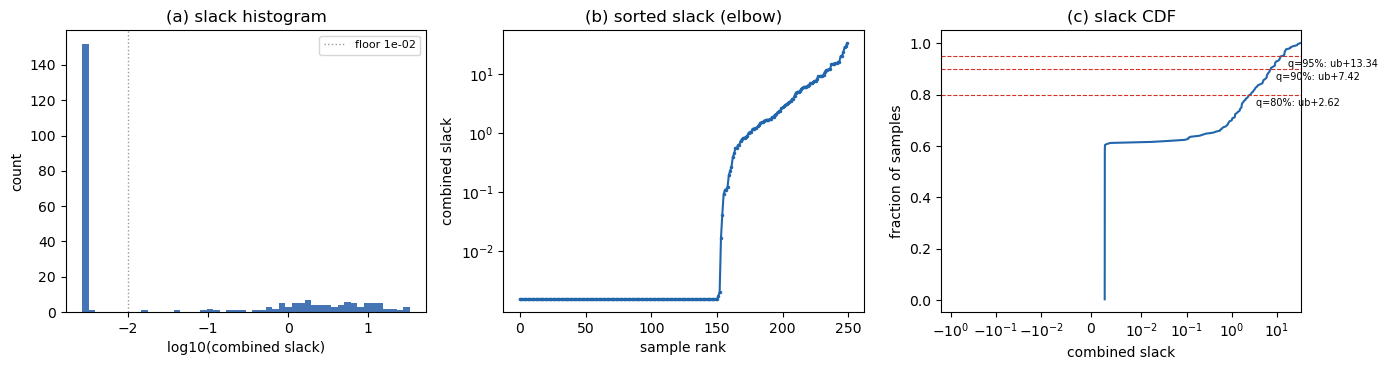

fraction with slack <= floor (1e-02): 61.2%  (feasible at ub_req with ~0 slack)


In [13]:
s = df["slack"].values
s_sorted = np.sort(s)
cdf = np.arange(1, len(s) + 1) / len(s)
FLOOR = PARAMS["slack_floor"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
ax = axes[0]
ax.hist(np.log10(np.clip(s, 1e-3, None)), bins=50, color="#4575b4")
ax.axvline(np.log10(FLOOR), color="#999999", ls=":", lw=1, label=f"floor {FLOOR:.0e}")
ax.set_xlabel("log10(combined slack)")
ax.set_ylabel("count")
ax.set_title("(a) slack histogram")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(np.arange(len(s)), s_sorted, ".-", ms=3, color="#2166ac")
ax.set_xlabel("sample rank")
ax.set_ylabel("combined slack")
ax.set_title("(b) sorted slack (elbow)")
ax.set_yscale("symlog", linthresh=1e-2)

ax = axes[2]
ax.plot(s_sorted, cdf, color="#2166ac")
for q in (0.8, 0.9, 0.95):
    thr = np.quantile(s, q)
    ax.axhline(q, color="#d73027", ls="--", lw=0.8)
    ax.annotate(
        f"q={q:.0%}: ub+{thr:.2f}",
        (thr, q),
        fontsize=7,
        xytext=(4, -8),
        textcoords="offset points",
    )
ax.set_xlabel("combined slack")
ax.set_ylabel("fraction of samples")
ax.set_title("(c) slack CDF")
ax.set_xscale("symlog", linthresh=1e-2)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_distribution.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

print(
    f"fraction with slack <= floor ({FLOOR:.0e}): {100*np.mean(s <= FLOOR):.1f}%  (feasible at ub_req with ~0 slack)"
)

## §3.2 — Where are the hard samples?

High-slack samples in $(x_1,x_2)$ and $(\theta,v)$, colored by combined slack; and slack vs each state coordinate. Reveals whether the hard samples cluster (e.g. low $v$, where the $1/v$ term inflates $|u|$).


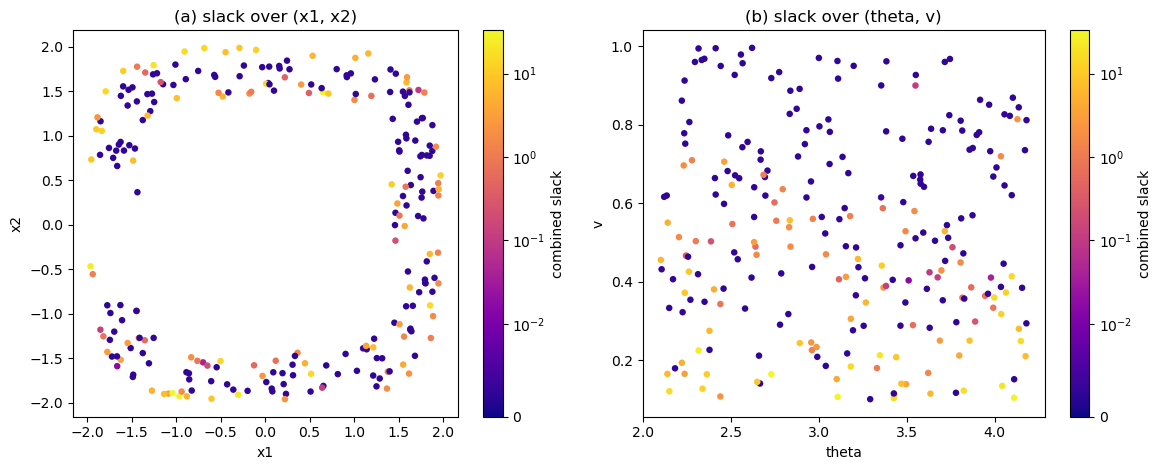

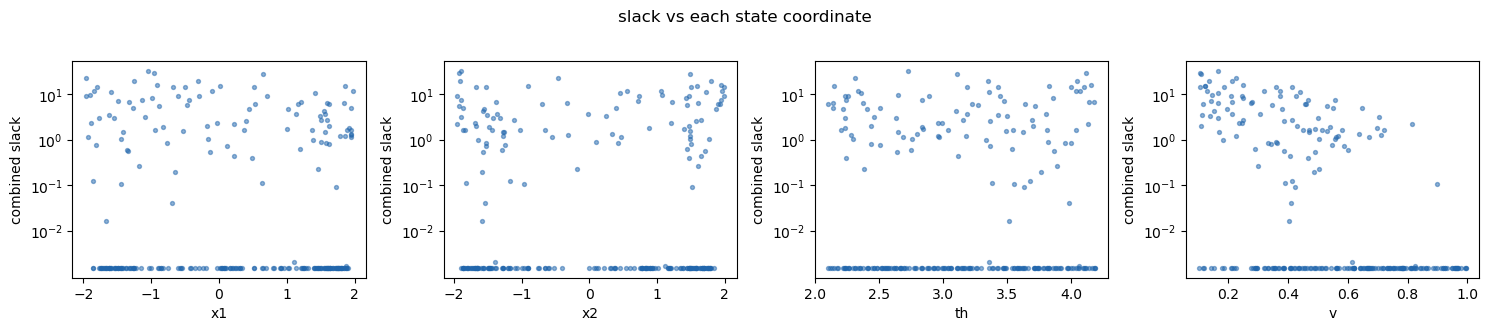

In [14]:
norm = mcolors.SymLogNorm(linthresh=1e-2, vmin=0, vmax=s.max())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (cx, cy, lx, ly) in zip(
    axes, [("x1", "x2", "x1", "x2"), ("th", "v", "theta", "v")]
):
    sc = ax.scatter(
        df[cx], df[cy], c=s, cmap="plasma", norm=norm, s=22, edgecolors="none"
    )
    plt.colorbar(sc, ax=ax, label="combined slack")
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
axes[0].set_title("(a) slack over (x1, x2)")
axes[0].set_aspect("equal")
axes[1].set_title("(b) slack over (theta, v)")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_spatial.png"), dpi=130, bbox_inches="tight"
)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, c in zip(axes, ["x1", "x2", "th", "v"]):
    ax.scatter(df[c], s, s=8, c="#2166ac", alpha=0.5)
    ax.set_xlabel(c)
    ax.set_ylabel("combined slack")
    ax.set_yscale("symlog", linthresh=1e-2)
fig.suptitle("slack vs each state coordinate", y=1.02)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_vs_state.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §4 — Selection criterion: effective bound $u_{\max}^{\rm eff}$ + kept subset

At coverage $q$ = `PARAMS['coverage_pct']`, keep the lowest-$q$ fraction by combined slack and set a **symmetric** effective bound

$$
u_{\max}^{\rm eff} = \mathrm{ub}_{\rm req} + \mathrm{quantile}_q(\{s_j\}),\qquad
\text{kept} = \{j : s_j \le \mathrm{quantile}_q\}.
$$

Every kept sample satisfies $|u_i|\le u_{\max}^{\rm eff}$ at the slack solution; this subset is fed to the Phase 1.3 hard SOP. Lower $q$ → tighter $u_{\max}^{\rm eff}$ but fewer kept samples. Change `coverage_pct` and re-run from §4 (no MATLAB re-run).


coverage = 80%  ->  slack threshold = 2.625
u_max_eff = ub_req + thr = 5.0 + 2.625 = 7.625
kept 200 / 250;  dropped 50 (highest-slack tail)
slack/ub_req = 0.52  ->  loose -> lower coverage or revisit region


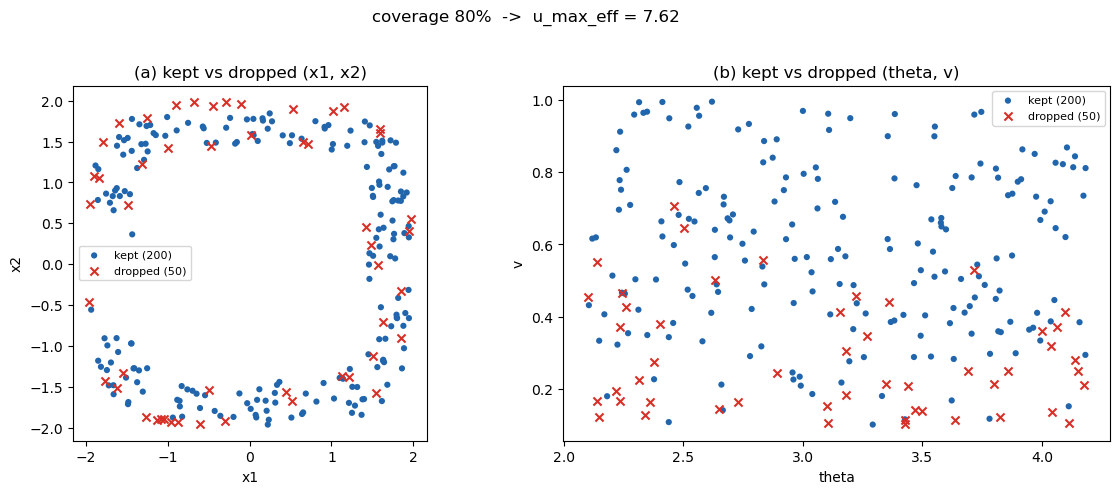

In [15]:
COVERAGE_PCT = PARAMS["coverage_pct"]
thr = float(np.percentile(s, COVERAGE_PCT))
ub_eff = UB_REQ + thr
kept = df[df["slack"] <= thr].copy()
dropped = df[df["slack"] > thr].copy()
ratio = thr / UB_REQ
verdict = (
    "tight (~nominal)"
    if ratio <= 0.05
    else (
        "acceptable" if ratio <= 0.30 else "loose -> lower coverage or revisit region"
    )
)

print(f"coverage = {COVERAGE_PCT}%  ->  slack threshold = {thr:.4g}")
print(f"u_max_eff = ub_req + thr = {UB_REQ} + {thr:.4g} = {ub_eff:.4g}")
print(f"kept {len(kept)} / {len(df)};  dropped {len(dropped)} (highest-slack tail)")
print(f"slack/ub_req = {ratio:.2f}  ->  {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (cx, cy, lx, ly) in zip(
    axes, [("x1", "x2", "x1", "x2"), ("th", "v", "theta", "v")]
):
    ax.scatter(
        kept[cx],
        kept[cy],
        s=20,
        c="#2166ac",
        label=f"kept ({len(kept)})",
        edgecolors="none",
    )
    ax.scatter(
        dropped[cx],
        dropped[cy],
        s=34,
        c="#d73027",
        marker="x",
        label=f"dropped ({len(dropped)})",
    )
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.legend(fontsize=8)
axes[0].set_title("(a) kept vs dropped (x1, x2)")
axes[0].set_aspect("equal")
axes[1].set_title("(b) kept vs dropped (theta, v)")
fig.suptitle(f"coverage {COVERAGE_PCT}%  ->  u_max_eff = {ub_eff:.3g}", y=1.02)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_kept.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §5 — Export Phase 1.2 outputs

`kept_samples_dubins.csv` (subset for Phase 1.3) and `phase1_2_outputs_dubins.json` (`u_max_eff`, coverage, threshold, probe params).


In [16]:
kept_path = os.path.join(REV_DATA, "kept_samples_dubins.csv")
kept[["sample_idx", "x1", "x2", "th", "v", "slack1", "slack2"]].to_csv(
    kept_path, index=False
)

out = {
    "phase": "1.2",
    "example": "dubins",
    "self_contained": True,
    "probe": {
        k: (float(meta[c]) if c in meta.index else PARAMS[k])
        for k, c in [
            ("mu", "mu"),
            ("xi0", "xi0"),
            ("ub", "ub_req"),
            ("slack_weight", "slack_weight"),
            ("ds", "ds"),
            ("dv", "dv"),
        ]
    }
    | {
        "lambda": float(meta["lambda"]),
        "delta": float(meta["delta"]),
        "n_samples": int(len(df)),
    },
    "coverage_pct": COVERAGE_PCT,
    "slack_threshold": thr,
    "u_max_eff": ub_eff,
    "u_max_eff_over_ub_req": ub_eff / UB_REQ,
    "n_kept": int(len(kept)),
    "n_dropped": int(len(dropped)),
    "kept_samples_csv": os.path.relpath(kept_path, ROOT),
    "slack_quantiles": {q: float(np.percentile(s, q)) for q in (50, 80, 90, 95, 99)},
    "notes": (
        "Per-sample slack SOP at ub_req; symmetric u_max_eff = ub_req + quantile_q(combined slack). "
        "Kept subset (combined slack <= q-quantile) feeds the Phase 1.3 hard SOP. All params set by "
        "this notebook; MATLAB solver may report approximate (near-boundary) status — slacks used for "
        "bound selection only."
    ),
}
out_path = os.path.join(REV_DATA, "phase1_2_outputs_dubins.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {kept_path}  ({len(kept)} rows)")
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/kept_samples_dubins.csv  (200 rows)
wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_2_outputs_dubins.json
{
  "phase": "1.2",
  "example": "dubins",
  "self_contained": true,
  "probe": {
    "mu": 0.1,
    "xi0": 1e-08,
    "ub": 5.0,
    "slack_weight": 100.0,
    "ds": 4.0,
    "dv": 4.0,
    "lambda": 1.09456316972482e-08,
    "delta": 152.342330461502,
    "n_samples": 250
  },
  "coverage_pct": 80,
  "slack_threshold": 2.624731743278106,
  "u_max_eff": 7.624731743278106,
  "u_max_eff_over_ub_req": 1.5249463486556212,
  "n_kept": 200,
  "n_dropped": 50,
  "kept_samples_csv": "revision/data/kept_samples_dubins.csv",
  "slack_quantiles": {
    "50": 0.0026984744941949,
    "80": 2.624731743278106,
    "90": 7.41900069093288,
    "95": 13.344240498149091,
    "99": 25.54221537228235
  },
  "notes": "Per-sample slack SOP at ub_req; symmetric u_max_eff = ub_req + quantile_q(comb